In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

$$\frac{d^2θ}{dt^2} = −ω^2_0 sin θ −γ\frac{dθ}{dt} + Acos(Ωt)$$

C:\Users\mrtlu\AppData\Local\Temp\ipykernel_12416\1596090104.py:31: ODEintWarning: Integration successful.
  u = odeint(self.odes, self.u0, t_prime, args=tuple(self.params), printmessg=True)


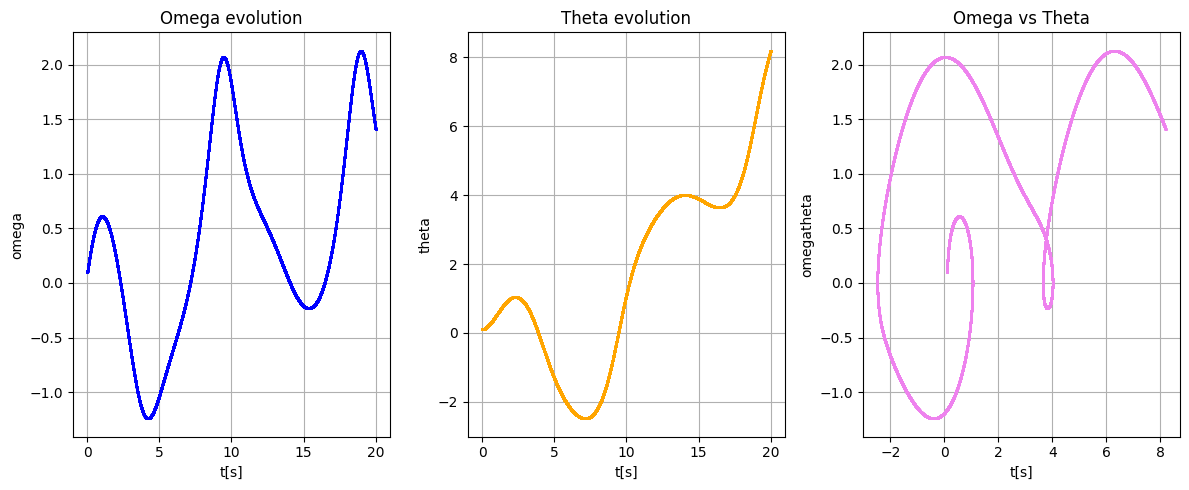

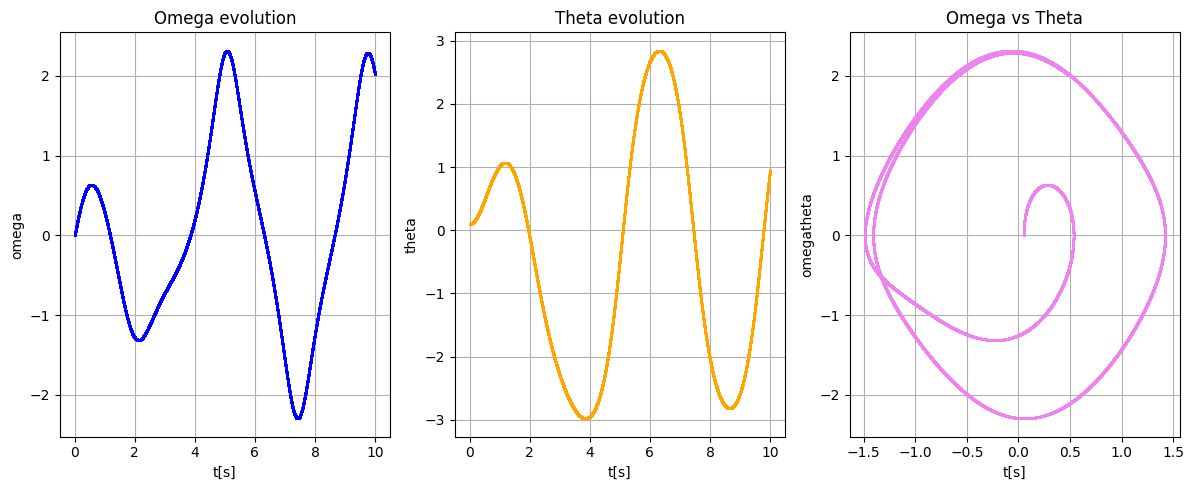

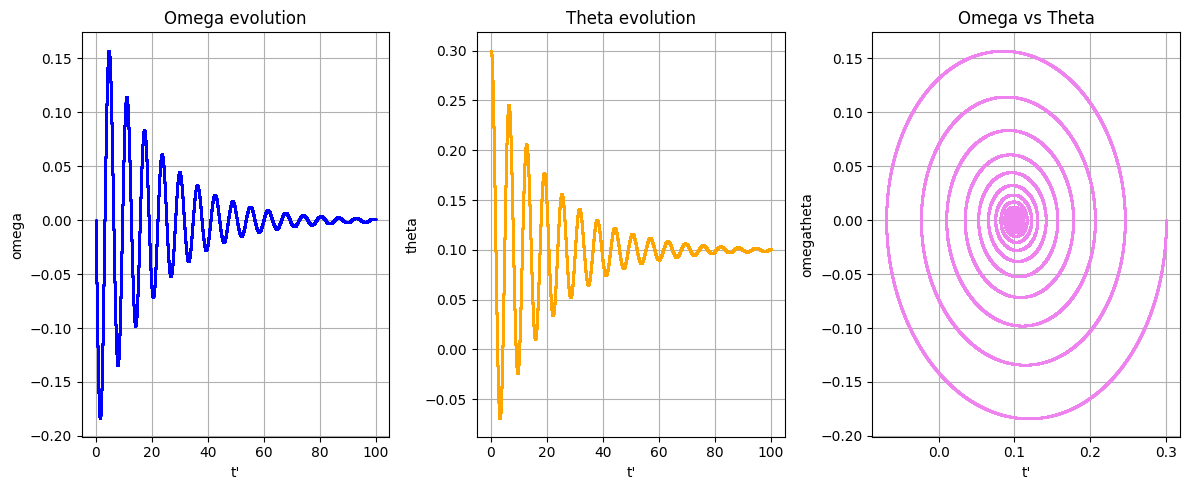

In [46]:
class Pendolum():
    def __init__(self, theta_t0, omega_t0, gamma, omega0, A,Omega):
        self.params=[gamma, omega0, A,Omega]
        self.u0=np.array([theta_t0, omega_t0])  

    def odes(self, u, t_prime, gamma, omega0, A, Omega): # it is (A x)
        """This function represents the first order ODEs to be integrated
        It returns the tuple (dx/dt, dv/dt), given u=(x,v) and t."""
        theta, omega = u
        return (omega, -np.sin(theta) - gamma/omega0 * omega + A/omega0 /omega0 * np.cos(Omega/omega0 * t_prime))

    def reset_u0(self, theta_t0=None, omega_t0=None):
        if theta_t0 != None:
            self.u0[0]=theta_t0
        if omega_t0 != None:
            self.u0[1]=omega_t0
    def reset_params(self, gamma=None, omega0=None, A=None,Omega=None):
        if gamma != None:
            self.params[0]=gamma
        if omega0 != None:
            self.params[1]=omega0
        if A != None:
            self.params[2]=A
        if Omega != None:
            self.params[3]=Omega
    
    def evolution(self, T, dt=0.001, t0=0.):
        # Prepare t, the sampling times
        t_prime = np.arange(t0, T, dt)
        # Solve the ODEs
        u = odeint(self.odes, self.u0, t_prime, args=tuple(self.params), printmessg=True)
        return u

    def display_evolution(self, T, *arg, dt=0.001, t0=0., tprime=True):
        u=self.evolution( T, dt=0.001, t0=0.)
        t_prime = np.arange(t0, T, dt)

        dictionary={'omega': {'title': "Omega evolution", 'var' : (t_prime, u[:, 1]), 'color': 'blue'},
                    'theta':  {'title': "Theta evolution", 'var' : (t_prime, u[:, 0]), 'color': 'orange'},
                    'omegatheta': {'title': "Omega vs Theta", 'var': (u[:,0], u[:, 1] ), 'color': 'violet' }
                    }
        if len(arg)!=0:
            fig, axes=plt.subplots(1, len(arg), figsize=(int(len(arg)*4), 5))
            if len(arg) == 1: axes = [axes]
            for key, ax in zip(arg, axes):
                ax.set_title(dictionary[key]['title'])

                ax.set_ylabel(key)

                if tprime:
                    ax.plot(dictionary[key]['var'][0], dictionary[key]['var'][1], '.', ms=2, color=dictionary[key]['color'])
                    ax.set_xlabel("t'")
                else:
                    ax.plot(dictionary[key]['var'][0]/self.params[1], dictionary[key]['var'][1], '.', ms=2, color=dictionary[key]['color'])
                    ax.set_xlabel("t[s]")
                ax.grid()

            plt.tight_layout()
            plt.show()



p1=Pendolum(0.1, 0.1, 0.5, 1,  1.07, 2/3)
p1.display_evolution(20. , 'omega', 'theta', 
                     'omegatheta'
                     ,

                     tprime=False
                     )

p2=Pendolum(0.1, 0, 1, 2,  4.6, 4./3)
p2.display_evolution(20. , 'omega', 'theta', 
                     'omegatheta'
                     ,

                     tprime=False
                     )


p3=Pendolum(0.3, 0, 1, 10,  10, 0)
p3.display_evolution(100. , 'omega', 'theta', 
                     'omegatheta',
                     )
